In [1]:
import pandas as pd
import pickle
import glob
import google_conf
import os
import json
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer

In [5]:
emlap_catalogue = google_conf.setup(sheet_url="https://docs.google.com/spreadsheets/d/1bkHHTYc86K2IuEXqfYfkDNt5LovtvCU3gvqHIbVio88/edit?usp=sharing", service_account_path="../../../ServiceAccountsKey.json")

In [33]:
# Get the data and transpose
emlap_metadata_raw = google_conf.get_as_dataframe(emlap_catalogue.worksheet("Copy_of_Catalogue_08_04_2025"), row=1, include_index=False)
emlap_metadata_raw.set_index("author_working", inplace=True)
emlap_metadata_raw.index.name = None
emlap_metadata= emlap_metadata_raw.T
emlap_metadata.index = emlap_metadata.index.astype(str)
emlap_metadata.head(5)

,No.,is_done,is_noscemus,if_noscemus_id,"#if is_noscemus = True, don't transcribe",AUTHORSHIP,is_one_author,#if more than 1 author skip section and choose compendium below,is_author_known,author_name,...,SOURCE OF FILE,link,source_of_file,origin_of_copy,REFERENCES,catalogue_reference,secondary_references,general_comments,OTHER,filename
"Augurello, Chrysopoeia",100001,True,True,713324,NaN,NaN,True,NaN,True,"Augurelli, Giovanni Aurelio",...,NaN,https://wiki.uibk.ac.at/noscemus/Chrysopoeia,Noscemus,Unknown,NaN,Noscemus Wiki,Soranzo 2019,The 1518 Basel version is also in Noscemus,NaN,NaN
"Pseudo-Lull, Secretis",100002,True,False,NaN,NaN,NaN,True,NaN,True,Pseudo-Lull,...,NaN,https://www.digitale-sammlungen.de/en/view/bsb...,MDZ,MBS,NaN,Hirsch 1950,NaN,"There is a prior, 1514 edition of De secretis ...",NaN,Pseudo-Lull1518_De_secretis_naturae_MDZ.pdf
"Pantheus, Ars Transmutatione",100003,True,False,NaN,NaN,NaN,True,NaN,True,"Panteo, Giovanni Agostino",...,NaN,NaN,GB,BL,NaN,NaN,NaN,This book was first published in 1518 with an ...,NaN,Pantheus1518_Ars_Transmutationis_Metallicae_BL...
"Pantheus, Commentarium",100004,True,False,NaN,NaN,NaN,True,NaN,True,"Panteo, Giovanni Agostino",...,NaN,https://www.digitale-sammlungen.de/en/view/bsb...,MDZ,MSB,NaN,NaN,NaN,This 1519 book is catalogued wrongly by many l...,NaN,Pantheus1519_Commentarium_Transmutationis_Meta...
"Pantheus, Voarchadumia",100005,True,False,NaN,NaN,NaN,True,NaN,True,"Panteo, Giovanni Agostino",...,NaN,NaN,ONB,ONB,NaN,NaN,NaN,Dedicated to Leonellus Marquis of Estense,NaN,Pantheus1530_Voarchadumia_ONB.pdf


In [38]:
id_label_dict = {}
for id, index, year in zip(emlap_metadata["No."], emlap_metadata["author_name"].astype(str), emlap_metadata["date_publication"]):
    id_label_dict[id] = index + " " + str(year)
id_label_dict

{100001: 'Augurelli, Giovanni Aurelio 1515',
 100002: 'Pseudo-Lull 1518',
 100003: 'Panteo, Giovanni Agostino 1518',
 100004: 'Panteo, Giovanni Agostino 1519',
 100005: 'Panteo, Giovanni Agostino 1530',
 100006: 'Savonarola, Michele 1532',
 100007: 'nan 1550',
 100008: 'Severinus, Petrus 1571',
 100009: 'nan 1518',
 100010: 'Bracesco, Giovanni 1548',
 100011: 'nan 1541',
 100012: 'Gessner, Conrad 1552',
 100013: 'Ulstadt, Philipp 1525',
 100014: 'Toxites, Michael 1567',
 100015: 'Gessner, Conrad 1569',
 100016: 'Bonus, Petrus 1546',
 100017: 'Bodenstein, Adam 1559',
 100018: 'Trevisanus, Bernhardus 1567',
 100019: 'Ulstadt, Philipp 1526',
 100020: 'Dorn, Gerard 1569',
 100021: 'Dorn, Gerard 1567',
 100022: 'nan 1550',
 100023: 'Paracelsus, Theophrastus von Hohenheim 1553',
 100024: 'Fanianus, Johannes Chrysippus 1560',
 100025: 'Pseudo-Lull 1563',
 100026: 'Garlandius 1560',
 100027: 'Paracelsus, Theophrastus von Hohenheim 1568',
 100028: 'Ruscelli, Girolamo 1563',
 100029: 'Paracelsus

In [68]:
lemmatized_sents_path = "/srv/data/tome/tome-corpus/lemmatized_sents_v3-0/"

In [69]:
os.listdir(lemmatized_sents_path)

['100032.txt',
 '100006.txt',
 '100069.txt',
 '100048.txt',
 '100029.txt',
 '100020.txt',
 '100059.txt',
 '100040.txt',
 '100030.txt',
 '100023.txt',
 '100031.txt',
 '100063.txt',
 '100010.txt',
 '100050.txt',
 '100047.txt',
 '100014.txt',
 '100052.txt',
 '100028.txt',
 '100021.txt',
 '100001.txt',
 '100026.txt',
 '100015.txt',
 '100008.txt',
 '100024.txt',
 '100035.txt',
 '100002.txt',
 '100012.txt',
 '100070.txt',
 '100037.txt',
 '100046.txt',
 '100068.txt',
 '100044.txt',
 '100038.txt',
 '100066.txt',
 '100025.txt',
 '100056.txt',
 '100057.txt',
 '100022.txt',
 '100013.txt',
 '100062.txt',
 '100042.txt',
 '100003.txt',
 '100019.txt',
 '100061.txt',
 '100071.txt',
 '100065.txt',
 '100074.txt',
 '100009.txt',
 '100007.txt',
 '100045.txt',
 '100058.txt',
 '100060.txt',
 '100017.txt',
 '100067.txt',
 '100043.txt',
 '100034.txt',
 '100039.txt',
 '100036.txt',
 '100055.txt',
 '100033.txt',
 '100049.txt',
 '100011.txt',
 '100072.txt',
 '100054.txt',
 '100004.txt',
 '100075.txt',
 '100016.t

In [85]:
filepath = lemmatized_sents_path + '100075.txt'
with open(filepath, 'r') as f:
    sents_lemmata = f.readlines()
sents_lemmata[90:150]

['corruptio corpus separo spiritus recipio aer chaos superior inferior firmamentum\n',
 'uita compositus elementum aqua fluxio destituo aqua morior\n',
 'uita ignis aer perseipse uiuo res elementatus uita tribuo\n',
 'Terra morior elementum inuisibilis occulo uita\n',
 'singulus considero\n',
 'uita herba planta radix liquor terra\n',
 'uita lignum insero resina\n',
 'uita resina terebinthinus gummus carabus muscilaginosa splendeo materia pinguedo\n',
 'uita dulcedinosor sacca mel manna cassia\n',
 'subtilis tingo dulcedo balsamitus uirtus dico\n',
 'uita unio splendor amitto calematio\n',
 'uita corallum gemma color elicio spiritus uinum\n',
 'uita sal spiritus aqua fortis\n',
 'uita sulphur combustibilis foeteo pinguedo\n',
 'uita lapis silex muscilaginosa materia\n',
 'uita marcasita cachimia talcum granatus combletus antimonium metallicus spiritingo\n',
 'uita argentum uiuus calor occulo manifestus frigus pelliceus uestis uideo exemplum\n',
 'uita metallum insero pinguedo terreus r

In [70]:
# Get all .txt files in the lemmatized_sents directory
filenames = []
file_paths = glob.glob(lemmatized_sents_path + '*.txt')
lemmata_all = []
docs_lemmata = []
for file_path in file_paths:
    filename = file_path.rpartition("/")[2]
    filenames.append(id)
    doc_lemmata = []
    with open(file_path, 'r') as f:
        lines = f.readlines()
        # Now 'lines' is a list where each element is a line from the file.
        for line in lines:
            # Process each line (each lemmatized sentence) here
            doc_lemmata.extend(line.strip().split())
    docs_lemmata.append(" ".join(doc_lemmata))
    lemmata_all.extend(doc_lemmata)

In [71]:
filenames[0]

100075

In [72]:
nltk.FreqDist(docs_lemmata[0].split()).most_common(50)

[('dico', 723),
 ('facio', 621),
 ('corpus', 606),
 ('argentum', 594),
 ('lapis', 577),
 ('ignis', 568),
 ('aqua', 489),
 ('natura', 460),
 ('aurum', 442),
 ('habeo', 363),
 ('possum', 323),
 ('sulphur', 315),
 ('pono', 300),
 ('pars', 298),
 ('fio', 293),
 ('res', 291),
 ('terra', 290),
 ('sal', 251),
 ('spiritus', 250),
 ('albus', 248),
 ('color', 244),
 ('philosophus', 242),
 ('opus', 242),
 ('materia', 235),
 ('liber', 230),
 ('metallum', 211),
 ('plumbum', 201),
 ('uas', 201),
 ('uirtus', 196),
 ('tingo', 194),
 ('uiuum', 190),
 ('ars', 188),
 ('medicina', 179),
 ('modus', 178),
 ('rubeus', 167),
 ('aer', 165),
 ('operatio', 158),
 ('uolo', 158),
 ('figo', 154),
 ('siccus', 149),
 ('primus', 147),
 ('uoco', 142),
 ('calidus', 141),
 ('calor', 135),
 ('sol', 135),
 ('uiuus', 133),
 ('elementum', 133),
 ('soluo', 133),
 ('bonus', 132),
 ('ferrum', 132)]

In [75]:
docs_lemmata[0]

"dicinus doctrina ratio conficio lapis philosophicus liber principes Palatinus accedo argumentum loannus Garlandius Anglus liber speculum magnus Uincentius liber priuilegium Caesar maieso principi D. Ottho Hennius Bauarius Dux sacer Romanus imperium elector uenio ciuis uenetus ars doctor foelicitas princeps optimus homo bonus ars studium compello omitto potissimus offero perquiro probus uir allicio gloriosus palester certamen maximus labor summus medius tollo uictoria praemium polliceor inquam scio naturalis Deus opten max do desiderium laus honor expetio fastigium otium uiuus sepulchrum uitium fomes expulsio ultimus resto beatus uiuo acquisitio annus secretior natura placeo medicus ars cognitio amor deuincio altior disciplina lapis occultus minor mundus Aristoteles uerbum utor Sisyphus molum uastus destino medius unda natator Delium iactatus delitesco difficilis uita mors taedeo procedo do reuertor infestus procella acerbitas pauor damnum sequor permitto scopulus allido deo premo lux 

In [81]:
nltk.FreqDist([l for doc in docs_lemmata for l in doc.split()]).most_common(100)


[('aqua', 19987),
 ('facio', 16031),
 ('possum', 14364),
 ('dico', 14091),
 ('natura', 12962),
 ('corpus', 12498),
 ('ignis', 11634),
 ('habeo', 9808),
 ('res', 8932),
 ('pars', 8338),
 ('aurum', 7614),
 ('argentum', 7389),
 ('oleum', 6977),
 ('lapis', 6814),
 ('materia', 6743),
 ('terra', 6573),
 ('spiritus', 6558),
 ('ars', 6337),
 ('fio', 6286),
 ('uideo', 6046),
 ('metallum', 5676),
 ('modus', 5535),
 ('pono', 5428),
 ('primus', 5354),
 ('sulphur', 5301),
 ('opus', 5208),
 ('uinum', 4610),
 ('albus', 4444),
 ('philosophus', 4406),
 ('dies', 4375),
 ('liber', 4370),
 ('uas', 4246),
 ('sal', 4140),
 ('uirtus', 4135),
 ('forma', 4132),
 ('elementum', 4117),
 ('uerus', 4034),
 ('homo', 3972),
 ('destillo', 3879),
 ('locus', 3809),
 ('uolo', 3729),
 ('aer', 3709),
 ('calor', 3709),
 ('ratio', 3637),
 ('tingo', 3620),
 ('debeo', 3611),
 ('color', 3594),
 ('Deus', 3566),
 ('uis', 3563),
 ('substantia', 3392),
 ('naturalis', 3209),
 ('magnus', 3175),
 ('misceo', 3088),
 ('uita', 3079),
 ('

In [111]:
labels = [id_label_dict[id] for id in filenames]
labels[:10]

['Morienus 1559',
 'Pseudo-Paracelsus, Centum quindecim curationes 1582',
 'Ventura 1571',
 'Garlandius 1560',
 'Rupescissa 1561',
 'Fanianus 1560',
 'Trevisan 1567',
 'Ulstadt De epidemia 1526',
 'Pseudo-Lull, Codicillus 1563',
 'Phaedro, De aquila 1562']

In [112]:
len(lemmata_all)

667943

In [113]:
vocab = [tup[0] for tup in nltk.FreqDist(lemmata_all).most_common(5000)]
vocab[:5]

['aqua', 'facio', 'omnis', 'dico', 'possum']

In [114]:
len(vocab)

5000

In [115]:
docs_lemmata[0]

'morieni romanus eremitae hierosolymitanus transfiguratio metallum occulo summus antiquus philosophus medicinus libellus lux edo priuilegio parisiis gulielmus guillard uia iacobaea diui barbara signum lex regia cautus gulielmus guillard imprimo libellus morienus romanus transfiguratio metallorum impresdo diuendo finis regnum decennius candidus lectori salutem oculus tuus offero auriferus ars libellus paucus uisus multus optatus scriptores inferus aetas laudo locus proferrem breuitas studium ueto arabicus sermo latinus conuerto peruetustus exemplarium nacti alter interperno nomen praefero alter supprimo loquendi modus translator disssideo collatio deprehendio dextere uerbum latini morienus sententia aperio incertus hincocinna loquela multus intersum desideror otiosus reperio alioquus res congruo excipio locus scriba uitium deprauo castrensis conuersio paruus gratus emitto alter margo ascribo discrepantia ago res momentum faxit deus que labor fructuosus ualis irrisori sapientia omnes chr

In [122]:
# Create the vectorizer
vectorizer = TfidfVectorizer(vocabulary=vocab)

# Apply the vectorizer
X = vectorizer.fit_transform(docs_lemmata)

# Getting the shape of X
print("Shape of X :", X.shape)

# Getting the TF-IDF matrix
tf_idf_matrix = X.toarray()

Shape of X : (31, 5000)


In [123]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Run t-SNE
tsne = TSNE(n_components=2, metric='cosine')  # Use 'cosine' as the distance metric
X_embedded = tsne.fit_transform(X.toarray())  # Convert sparse matrix X to dense

(3.2634021520614622,
 3.3790972948074343,
 0.20349040850996972,
 0.30338437631726267)

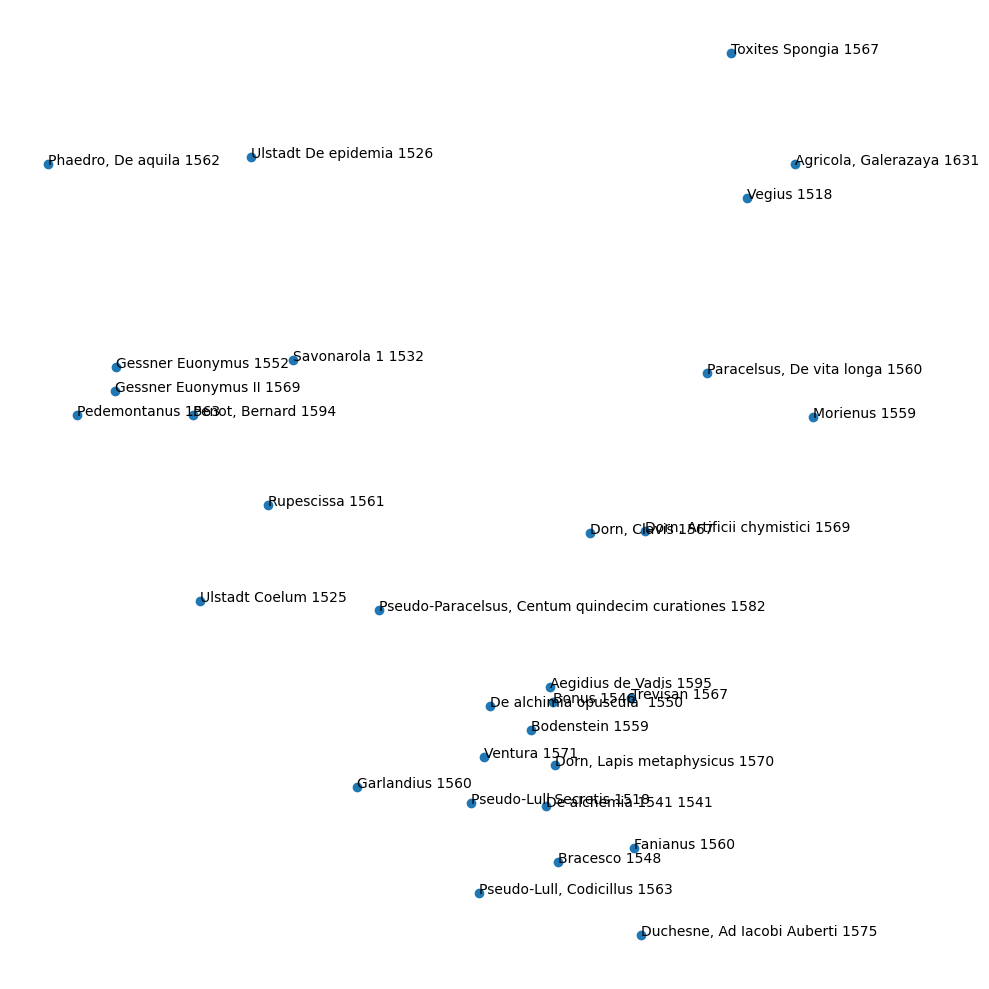

In [124]:
fig, ax = plt.subplots(figsize=(10, 10), tight_layout=True)
# Plot the results
ax.scatter(X_embedded[:, 0], X_embedded[:, 1])

for i, label in enumerate(labels):
    ax.annotate(label, (X_embedded[i, 0], X_embedded[i, 1]))


ax.axis('off')  # Hide axis

In [125]:
fig.savefig('../figures/tsne_tfidf_v1.png')

In [5]:
# Get all .txt files in the lemmatized_sents directory
file_paths = glob.glob("/srv/data/tome/tome-corpus/sents_data_jsons_v2-0/*.json")
sents_n = 0
tokens_n = 0
for file_path in file_paths:
    #id = file_path.rpartition("/")[2].partition(".")[0]
    #ids.append(id)
    with open(file_path, 'r') as f:
       file_sents_data = json.load(f)
       sents_n += len(file_sents_data)
       for sent_data in file_sents_data:
           tokens_n += len(sent_data[3])

In [6]:
print(tokens_n)

2672694


In [7]:
print(sents_n)

167913
